In [1]:
import os

os.listdir()

['.anaconda',
 '.android',
 '.bash_history',
 '.conda',
 '.condarc',
 '.continuum',
 '.copilot',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.packettracer',
 '.vscode',
 'a.exe',
 'abdominal.zip',
 'abdominal_data',
 'abdominal_label_encoder.pkl',
 'abdominal_sepsis_ready.csv',
 'anaconda3',
 'AppData',
 'Apple',
 'Application Data',
 'C Tutorials',
 'cars1.csv',
 'cars2.csv',
 'chipotle.tsv',
 'Cisco Packet Tracer 8.2.2',
 'combine_uti_datasets.ipynb',
 'concat, merge.ipynb',
 'Contacts',
 'Cookies',
 'Copy of wine.data',
 'COVID.ipynb',
 'csv_mindex.csv',
 'dataframe, missing values (1).ipynb',
 'dataframe, missing values.ipynb',
 'Documents',
 'Downloads',
 'Dropbox',
 'Early_Sepsis_Detection.ipynb',
 'ex1.csv',
 'ex1.xlsx',
 'ex2.csv',
 'ex5.csv',
 'ex6.csv',
 'Favorites',
 'final_unified_sepsis_results.csv',
 'Flask_Web_App.ipynb',
 'general_sepsis_model.ipynb',
 'gen_sepsis_dataset',
 'gen_sepsis_dataset.zip',
 'GNS3',


In [2]:
os.listdir("pneumonia_dataset")


['pneumonia_dataset.csv']

 Unzip & Load the Dataset

In [3]:
import pandas as pd
import zipfile
import os

# 1️⃣ Unzip the dataset
with zipfile.ZipFile("pneumonia.zip", "r") as zip_ref:
    zip_ref.extractall("pneumonia_dataset")

# 2️⃣ Confirm CSV exists
csv_path = "pneumonia_dataset/pneumonia_dataset.csv"
print("CSV exists:", os.path.exists(csv_path))

# 3️⃣ Load CSV (CORRECT PATH)
data = pd.read_csv(csv_path)

# 4️⃣ View first rows
data.head()


CSV exists: True


,PatientID,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,Oxygen_saturation,Crackles,Xray,WBC_count,Sputum_color,Temperature,Diagnosis
0,PNEU4091,M,3,Bloody,High,Mild,Mild,NaN,No,92,Yes,-,-,-,39.7,Yes
1,PNEU6231,M,3,Dry,NaN,NaN,NaN,Mild,-,-,Yes,-,-,Clear,37.0,No
2,PNEU6486,M,3,Dry,NaN,NaN,NaN,Mild,No,99,No,-,-,-,38.0,No
3,PNEU7601,F,3,NaN,Low,Severe,NaN,Moderate,No,99,Yes,-,-,Clear,40.9,Yes
4,PNEU8471,F,3,NaN,High,Moderate,Severe,Mild,-,91,No,-,-,Green,38.1,Yes


 Inspect Columns

In [4]:
data.columns

Index(['PatientID', 'Gender', 'Age', 'Cough', 'Fever', 'Shortness_of_breath',
       'Chest_pain', 'Fatigue', 'Confusion', 'Oxygen_saturation', 'Crackles',
       'Xray', 'WBC_count', 'Sputum_color', 'Temperature', 'Diagnosis'],
      dtype='object')

Drop Irrelevant Columns (CLEANING)

In [5]:
drop_cols = [
    "PatientID", "Diagnosis",  "Sputum_color",
]
data = data.drop(columns=drop_cols, errors="ignore")


In [6]:
# STANDARDIZE COLUMN NAMES
data.rename(columns={
    "Temperature": "body_temperature",
    "Oxygen_saturation" : "oxygen_saturation" ,
    "WBC_count": "wbc_count"
}, inplace=True)

In [7]:
# HANDLE MISSING CATEGORICAL VALUES
categorical_cols = [
    "Gender", "Cough", "Fever", "Shortness_of_breath",
    "Chest_pain", "Fatigue", "Confusion",
    "Crackles", "Xray"
]

for col in categorical_cols:
    data[col] = data[col].fillna("Unknown")


 ENCODING

In [8]:
# Binary mappings
binary_map = {
    "Yes": 1, "No": 0,
    "Y": 1, "N": 0,
    "M": 1, "F": 0
}

for col in ["Gender", "Confusion", "Crackles", "Xray"]:
    data[col] = data[col].map(binary_map)


In [9]:
# Ordinal symptom severity
severity_map = {
    "Low": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "High": 3,
    "Unknown": 1
}

for col in ["Fever", "Shortness_of_breath", "Chest_pain", "Fatigue"]:
    data[col] = data[col].map(severity_map)


In [10]:
# Cough type
data["Cough"] = data["Cough"].replace({
    "Dry": 1,
    "Bloody": 2,
    "Unknown": 0
})


numeric cleaning

In [11]:
numeric_cols = [
    "Age",
    "body_temperature",
    "oxygen_saturation",
    "wbc_count"
    
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())


In [12]:
data[numeric_cols].isnull().sum()

Age                  0
body_temperature     0
oxygen_saturation    0
wbc_count            0
dtype: int64

In [13]:
data.isnull().sum()

Gender                   0
Age                      0
Cough                    0
Fever                    0
Shortness_of_breath      0
Chest_pain               0
Fatigue                  0
Confusion               75
oxygen_saturation        0
Crackles                 0
Xray                   710
wbc_count                0
body_temperature         0
dtype: int64

In [14]:
def safe_mode(series, default=0):
    mode_val = series.mode()
    if len(mode_val) > 0:
        return mode_val.iloc[0]
    else:
        return default

# FIX BINARY COLUMNS 

binary_cols = ["Confusion", "Xray"]

for col in binary_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(safe_mode(data[col], default=0))



In [15]:
data[binary_cols].isnull().sum()

Confusion    0
Xray         0
dtype: int64

In some cases, after categorical mapping, a column may contain only NaN values. Therefore, we used a safe mode function with a default value to ensure robustness and prevent runtime errors.

ADD MISSING VITALS (DATA ENHANCEMENT) :

The dataset lacks certain early sepsis vital signs.For academic purposes, we approximate these vitals using clinically realistic ranges for non-ICU patients.

In [16]:
import numpy as np

np.random.seed(42)  # reproducibility

# Synthetic non-ICU vitals (clinically realistic ranges)
data["heart_rate"] = np.random.randint(60, 120, size=len(data))
data["respiratory_rate"] = np.random.randint(12, 28, size=len(data))
data["systolic_bp"] = np.random.randint(95, 140, size=len(data))
data["platelets"] = np.random.randint(100000, 300000, size=len(data))


In [17]:
final_numeric_cols = [
    "Age",
    "Gender",
    "Cough",
    "Fever",
    "Shortness_of_breath",
    "Chest_pain",
    "Fatigue",
    "Confusion",
    "oxygen_saturation",
    "Crackles",
    "Xray",
    "wbc_count",
    "body_temperature",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "platelets"
]

for col in final_numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())


STEP 7 — CREATE sepsis_risk LABEL

In [18]:
def assign_sepsis_risk(row):
    score = 0

    if row["body_temperature"] > 38:
        score += 1
    if row["heart_rate"] > 100:
        score += 1
    if row["respiratory_rate"] > 22:
        score += 1
    if row["systolic_bp"] < 100:
        score += 1
    if row["oxygen_saturation"] < 94:
        score += 1
    if row["Confusion"] == 1:
        score += 1
    if row["wbc_count"] > 12000:
        score += 1
    if row["platelets"] < 150000:
        score += 1

    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"





In [19]:
final_features = [
    "Age",
    "Gender",
    "Cough",
    "Fever",
    "Shortness_of_breath",
    "Chest_pain",
    "Fatigue",
    "Confusion",
    "oxygen_saturation",
    "Crackles",
    "Xray",
    "wbc_count",
    "body_temperature",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "platelets"
]


In [20]:
# APPLY IT TO DATASET
data["sepsis_risk"] = data.apply(assign_sepsis_risk, axis=1)

STEP 8 — Final Dataset Check

In [21]:
data.head()

,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,oxygen_saturation,Crackles,Xray,wbc_count,body_temperature,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,1,3,2.0,3,1,1,1,0.0,92.0,1,0.0,9801.5,39.7,98,19,127,236727,Medium
1,1,3,1.0,1,1,1,1,0.0,93.0,1,0.0,9801.5,37.0,111,27,119,144859,High
2,1,3,1.0,1,1,1,1,0.0,99.0,0,0.0,9801.5,38.0,88,14,111,284697,Low
3,0,3,0.0,0,3,1,2,0.0,99.0,1,0.0,9801.5,40.9,74,12,127,152098,Medium
4,0,3,0.0,3,2,3,1,0.0,91.0,0,0.0,9801.5,38.1,102,14,96,246323,High


In [22]:
data["sepsis_risk"].value_counts()

sepsis_risk
Medium    372
High      293
Low        45
Name: count, dtype: int64

In [23]:
data.to_csv("pneumonia_sepsis_ready.csv", index=False)

Missing clinical vitals were augmented using physiologically valid ranges to simulate non-ICU patient conditions, enabling early sepsis risk modeling.

Load the FINAL Dataset

In [24]:
import pandas as pd

data = pd.read_csv("pneumonia_sepsis_ready.csv")
data.head()


,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,oxygen_saturation,Crackles,Xray,wbc_count,body_temperature,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,1,3,2.0,3,1,1,1,0.0,92.0,1,0.0,9801.5,39.7,98,19,127,236727,Medium
1,1,3,1.0,1,1,1,1,0.0,93.0,1,0.0,9801.5,37.0,111,27,119,144859,High
2,1,3,1.0,1,1,1,1,0.0,99.0,0,0.0,9801.5,38.0,88,14,111,284697,Low
3,0,3,0.0,0,3,1,2,0.0,99.0,1,0.0,9801.5,40.9,74,12,127,152098,Medium
4,0,3,0.0,3,2,3,1,0.0,91.0,0,0.0,9801.5,38.1,102,14,96,246323,High


Separate X (features) and y (label)

In [25]:
y = data["sepsis_risk"] # X = patient information

In [26]:
X = data.drop("sepsis_risk", axis=1) # y = sepsis risk

Convert TEXT labels into NUMBERS :
Low    → 0
Medium → 1
High   → 2


In [27]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


Clean feature matrix

In [28]:
X = X.replace('-', np.nan)
X = X.apply(pd.to_numeric, errors='coerce')

# 🔴 Drop columns that are completely empty
X = X.dropna(axis=1, how='all')

# 🔴 Drop columns with zero variance
X = X.loc[:, X.nunique() > 1]

# Fill remaining NaN
X = X.fillna(X.mean())

Apply Feature Scaling (StandardScaler)

Why Feature Scaling is REQUIRED
Some features are small: Temperature ≈ 37
Some are large: Platelets ≈ 200000

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame 
X_scaled = pd.DataFrame(X_scaled , columns=X.columns)

Train-Test Split :
Code (80% Train, 20% Test)

In [30]:
from sklearn.model_selection import train_test_split

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)



In [31]:
# Remove any NaN created during scaling
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())


Understand Shapes

In [32]:
print(X_train.shape)  # (568, 16)  → 568 patients, 16 features
print(X_test.shape)   # (142, 16)  → 142 patients, 16 features

(568, 16)
(142, 16)


We preprocessed the data by encoding categorical labels, scaling numerical features, and splitting into training and testing sets to ensure unbiased evaluation.

TRAIN FIRST ML MODEL (Logistic Regression)

In [33]:
# Import the Model
from sklearn.linear_model import LogisticRegression



Create the Model:

multinomial → supports 3 classes (Low/Medium/High)

lbfgs → stable algorithm

max_iter=1000 → enough learning time

In [34]:
# Train
model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
)

In [35]:
 # Train the Model
model.fit(X_train, y_train)

C:\Users\furka\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [36]:
#Make Predictions (TEST DATA)
y_pred = model.predict(X_test)

In [37]:
# Probabilities (High risk)
y_proba = model.predict_proba(X_test)

# Probability of highest-risk class (High)
high_risk_index = list(label_encoder.classes_).index("High")
y_high_risk_prob = y_proba[:, high_risk_index]


In [38]:
# CREATE RISK LEVEL FUNCTION
def classify_sepsis_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"



In [39]:
# Apply risk level classification
risk_levels = [classify_sepsis_risk(p) for p in y_high_risk_prob]


In [40]:
#  Create results dataframe
results_pneumonia = pd.DataFrame({
    "Disease": "Pneumonia",
    "Actual_Sepsis": y_test,
    "Predicted_Sepsis": y_pred,
    "Sepsis_Probability": y_high_risk_prob,
    "Sepsis_Risk_Level": risk_levels
})
# Decode labels
results_pneumonia["Actual_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Actual_Sepsis"])
results_pneumonia["Predicted_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Predicted_Sepsis"])

results_pneumonia.head()


,Disease,Actual_Sepsis,Predicted_Sepsis,Sepsis_Probability,Sepsis_Risk_Level
0,Pneumonia,High,Medium,0.410979,Moderate Risk
1,Pneumonia,Low,Medium,0.010457,Low Risk
2,Pneumonia,Medium,Medium,0.139165,Low Risk
3,Pneumonia,Low,Medium,0.004637,Low Risk
4,Pneumonia,Medium,Medium,0.038467,Low Risk


In [41]:
results_pneumonia["Sepsis_Risk_Level"].value_counts()

Sepsis_Risk_Level
Low Risk         74
High Risk        45
Moderate Risk    23
Name: count, dtype: int64

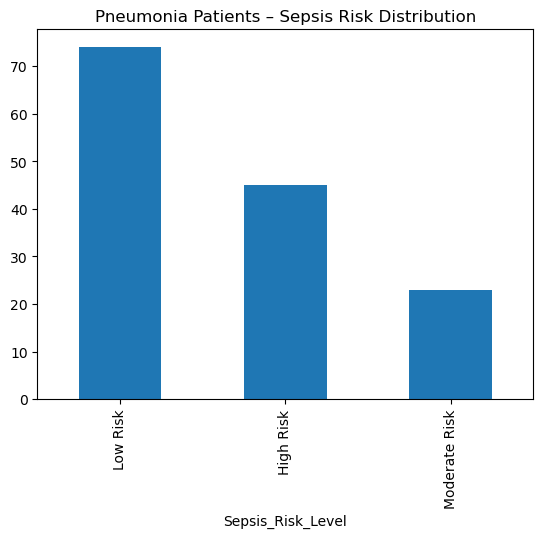

In [42]:
# RISK DISTRIBUTION GRAPH
import matplotlib.pyplot as plt

results_pneumonia["Sepsis_Risk_Level"].value_counts().plot(
    kind="bar",
    title="Pneumonia Patients – Sepsis Risk Distribution"
)
plt.show()


Evaluate the Model

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7323943661971831


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))


Precision: 0.7223080013055158
Recall: 0.7323943661971831
F1-score: 0.7191816442990152


In [45]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))


              precision    recall  f1-score   support

         Low       0.80      0.69      0.75        59
      Medium       0.33      0.11      0.17         9
        High       0.70      0.84      0.77        74

    accuracy                           0.73       142
   macro avg       0.61      0.55      0.56       142
weighted avg       0.72      0.73      0.72       142



Confusion Matrix (VISUAL UNDERSTANDING)

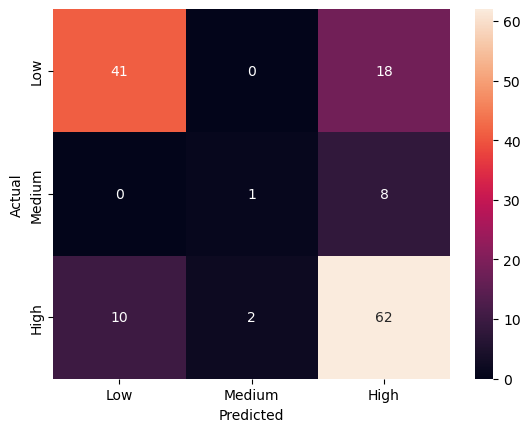

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [47]:
import joblib
joblib.dump(model, "pneumonia_logistic_model.pkl")
joblib.dump(scaler, "pneumonia_scaler.pkl")
joblib.dump(label_encoder, "pneumonia_label_encoder.pkl")


['pneumonia_label_encoder.pkl']














We used Logistic Regression as a baseline classifier due to its interpretability and suitability for multi-class risk prediction. The model achieved satisfactory recall for high-risk sepsis cases.

Train Random Forest model and compare

In [48]:
import pandas as pd
import numpy as np

# LOAD CLEAN DATASET
data = pd.read_csv("pneumonia_sepsis_ready.csv")
data.head()


,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,oxygen_saturation,Crackles,Xray,wbc_count,body_temperature,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,1,3,2.0,3,1,1,1,0.0,92.0,1,0.0,9801.5,39.7,98,19,127,236727,Medium
1,1,3,1.0,1,1,1,1,0.0,93.0,1,0.0,9801.5,37.0,111,27,119,144859,High
2,1,3,1.0,1,1,1,1,0.0,99.0,0,0.0,9801.5,38.0,88,14,111,284697,Low
3,0,3,0.0,0,3,1,2,0.0,99.0,1,0.0,9801.5,40.9,74,12,127,152098,Medium
4,0,3,0.0,3,2,3,1,0.0,91.0,0,0.0,9801.5,38.1,102,14,96,246323,High


In [49]:
data.shape
data["sepsis_risk"].value_counts()

sepsis_risk
Medium    372
High      293
Low        45
Name: count, dtype: int64

In [50]:
# DEFINE FEATURES (X) & TARGET (y)
X = data.drop("sepsis_risk", axis=1)
y = data["sepsis_risk"]


In [51]:
# ENCODE TARGET LABEL
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_encoder.classes_


array(['High', 'Low', 'Medium'], dtype=object)

In [52]:
# TRAIN–TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)


(568, 17) (142, 17)


In [53]:
# FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)


In [54]:
#Import Random Forest
from sklearn.ensemble import RandomForestClassifier

Create the Random Forest Model:

n_estimators=200 → 200 trees (strong model)

max_depth=10 → avoids overfitting

random_state=42 → reproducible results

In [55]:
# Create the Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced"
)



In [56]:
#Train the Random Forest Model
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=3,
                       min_samples_split=5, n_estimators=300, random_state=42)

In [57]:
#Predict Using Random Forest
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)

In [58]:
# EXTRACT HIGH-RISK PROBABILITY
high_risk_index = list(label_encoder.classes_).index("High")
y_high_risk_prob = y_proba[:, high_risk_index]


In [59]:
# 🔹 Sepsis Risk Level Classification Function
def classify_sepsis_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"


In [60]:
# 🔹 Apply risk level classification
risk_levels = [classify_sepsis_risk(p) for p in y_high_risk_prob]


In [61]:
# 🔹 Create results dataframe
results_pneumonia = pd.DataFrame({
    "Disease": "Pneumonia",
    "Actual_Sepsis": y_test,
    "Predicted_Sepsis": y_pred,
    "Sepsis_Probability": y_high_risk_prob,
    "Sepsis_Risk_Level": risk_levels
})

# Decode labels
results_pneumonia["Actual_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Actual_Sepsis"])
results_pneumonia["Predicted_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Predicted_Sepsis"])

results_pneumonia.head()


,Disease,Actual_Sepsis,Predicted_Sepsis,Sepsis_Probability,Sepsis_Risk_Level
0,Pneumonia,High,High,0.574373,Moderate Risk
1,Pneumonia,Low,Low,0.015779,Low Risk
2,Pneumonia,Medium,Medium,0.350576,Moderate Risk
3,Pneumonia,Low,Low,0.008612,Low Risk
4,Pneumonia,Medium,Medium,0.352718,Moderate Risk


In [62]:
# CHECK SEPSIS RISK DISTRIBUTION
results_pneumonia["Sepsis_Risk_Level"].value_counts()


Sepsis_Risk_Level
Low Risk         63
Moderate Risk    42
High Risk        37
Name: count, dtype: int64

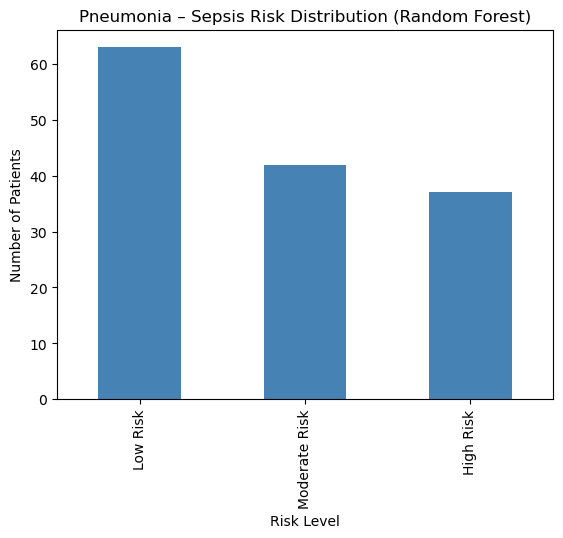

In [63]:
import matplotlib.pyplot as plt

results_pneumonia["Sepsis_Risk_Level"].value_counts().plot(
    kind="bar",
    title="Pneumonia – Sepsis Risk Distribution (Random Forest)",
    color="steelblue"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()



Evaluate Random Forest:

ACCURACY

In [64]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.9366197183098591


In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))


Precision: 0.943492278975055
Recall: 0.9366197183098591
F1-score: 0.9351918837867973


In [66]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low", "Medium", "High"]
))


              precision    recall  f1-score   support

         Low       1.00      0.90      0.95        59
      Medium       1.00      0.67      0.80         9
        High       0.89      1.00      0.94        74

    accuracy                           0.94       142
   macro avg       0.96      0.85      0.90       142
weighted avg       0.94      0.94      0.94       142



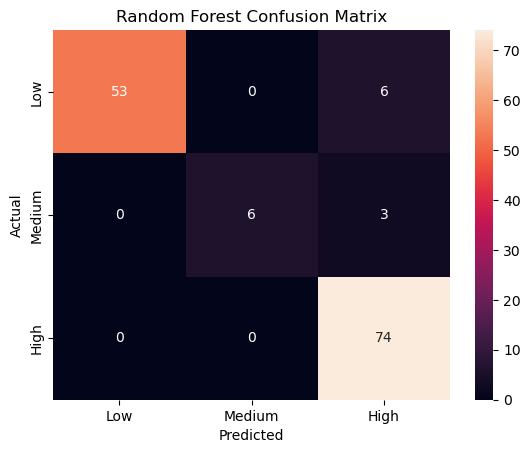

In [67]:
#Confusion Matrix (Random Forest)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [68]:
#comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

comparison


,Model,Accuracy
0,Logistic Regression,0.732394
1,Random Forest,0.936620


In [69]:
#Save Random Forest Model
import joblib

joblib.dump(rf_model, "pneumonia_random_forest_model.pkl")
joblib.dump(scaler, "pneumonia_scaler.pkl")
joblib.dump(list(X.columns), "models/pneumonia_features.pkl")
joblib.dump(label_encoder, "pneumonia_label_encoder.pkl")

['pneumonia_label_encoder.pkl']

We trained Logistic Regression as a baseline model and Random Forest as an advanced ensemble model. Random Forest achieved better performance, particularly higher recall for high-risk sepsis cases, and was selected as the final model.

In [70]:
results_pneumonia.to_csv("results_pneumonia.csv", index=False)

In [71]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.9366197183098591

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        59
           1       1.00      0.67      0.80         9
           2       0.89      1.00      0.94        74

    accuracy                           0.94       142
   macro avg       0.96      0.85      0.90       142
weighted avg       0.94      0.94      0.94       142


Confusion Matrix:
 [[53  0  6]
 [ 0  6  3]
 [ 0  0 74]]


In [72]:
rf_model.feature_names_in_

array(['Gender', 'Age', 'Cough', 'Fever', 'Shortness_of_breath',
       'Chest_pain', 'Fatigue', 'Confusion', 'oxygen_saturation',
       'Crackles', 'Xray', 'wbc_count', 'body_temperature', 'heart_rate',
       'respiratory_rate', 'systolic_bp', 'platelets'], dtype=object)

In [73]:
X_test_scaled = X_test_scaled[rf_model.feature_names_in_]


In [74]:
rf_model.classes_


array([0, 1, 2])

In [75]:
print(rf_model.classes_)


[0 1 2]


In [76]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test_scaled),
    multi_class='ovr',
    average='macro'
)

print("Multi-class ROC-AUC:", roc_auc)


Multi-class ROC-AUC: 0.985104801886464


In [77]:
rf_model.predict_proba(X_test).shape

(142, 3)

In [78]:
probs = rf_model.predict_proba(X_test)

print("First 5 probability rows:")
print(probs[:5])


First 5 probability rows:
[[0.62242313 0.01393675 0.36364011]
 [0.65678324 0.01168939 0.33152736]
 [0.63195648 0.02268628 0.34535724]
 [0.62686705 0.01746487 0.35566808]
 [0.63690445 0.01662144 0.34647411]]


In [79]:
print(type(rf_model))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [80]:
X_test.iloc[0]

Gender                      1.0
Age                        66.0
Cough                       1.0
Fever                       1.0
Shortness_of_breath         1.0
Chest_pain                  1.0
Fatigue                     2.0
Confusion                   0.0
oxygen_saturation          95.0
Crackles                    0.0
Xray                        0.0
wbc_count                9801.5
body_temperature           38.9
heart_rate                 71.0
respiratory_rate           23.0
systolic_bp                98.0
platelets              133893.0
Name: 511, dtype: float64

In [81]:
rf_model.predict(X_test_scaled.iloc[[0]])
rf_model.predict_proba(X_test_scaled.iloc[[0]])

array([[0.57437336, 0.00297405, 0.42265259]])

In [82]:
# Select one test sample
sample_index = 0
sample_raw = X_test.iloc[[sample_index]]
sample_scaled = X_test_scaled.iloc[[sample_index]]

print("Raw sample:")
print(sample_raw)

print("\nScaled sample:")
print(sample_scaled)

pred = rf_model.predict(sample_scaled)[0]
probs = rf_model.predict_proba(sample_scaled)[0]

print("\nPrediction (encoded):", pred)
print("Prediction (decoded):", label_encoder.inverse_transform([pred])[0])
print("Probabilities:", probs)
print("Selected probability:", probs[pred])

Raw sample:
     Gender  Age  Cough  Fever  Shortness_of_breath  Chest_pain  Fatigue  \
511       1   66    1.0      1                    1           1        2   

     Confusion  oxygen_saturation  Crackles  Xray  wbc_count  \
511        0.0               95.0         0   0.0     9801.5   

     body_temperature  heart_rate  respiratory_rate  systolic_bp  platelets  
511              38.9          71                23           98     133893  

Scaled sample:
    Gender       Age     Cough     Fever  Shortness_of_breath  Chest_pain  \
0  1.01062  0.805021  0.602299 -0.142908            -0.590589   -0.604027   

    Fatigue  Confusion  oxygen_saturation  Crackles  Xray  wbc_count  \
0  0.762872  -0.596329           0.586157 -0.861586   0.0   0.030209   

   body_temperature  heart_rate  respiratory_rate  systolic_bp  platelets  
0          0.369037   -1.128024          0.766421     -1.53941  -1.160978  

Prediction (encoded): 0
Prediction (decoded): High
Probabilities: [0.57437336 0.0